In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

laptops_eda = pd.read_excel("Data Analytics/gaming_laptops_2026_q1.xlsx")

laptops_eda.head()

,title,brand,price,list_price,discount_pct,price_currency,stars,reviews_count,breadCrumbs,description
0,Apple 2025 MacBook Air 13-inch Laptop with M4 ...,Apple,949.00,999.00,5.01,$,4.8,5991,NaN,NaN
1,Apple 2025 MacBook Pro Laptop with M5 chip wit...,Apple,1449.00,1599.00,9.38,$,4.7,1217,NaN,NaN
2,Lenovo Legion Pro 7i â€“ AI-Powered Gaming Lap...,Lenovo,2004.89,2149.99,6.75,$,4.3,139,Electronics > Computers & Accessories > Comput...,The Lenovo Legion Pro 7i is designed for eSpor...
3,LG 45GX950A-B 45-inch Ultragear 5K2K WUHD (512...,LG,1486.99,1999.99,25.65,$,4.3,323,Electronics > Computers & Accessories > Monitors,Unleash unparalleled gaming prowess with the w...
4,acer Nitro V Gaming Laptop | Intel Core i7-136...,acer,949.99,NaN,0.00,$,4.6,205,Electronics > Computers & Accessories > Comput...,Live For Victory: Elevate your gaming adventur...


In [3]:
laptops_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           614 non-null    object 
 1   brand           614 non-null    object 
 2   price           614 non-null    float64
 3   list_price      115 non-null    float64
 4   discount_pct    614 non-null    float64
 5   price_currency  614 non-null    object 
 6   stars           498 non-null    float64
 7   reviews_count   614 non-null    int64  
 8   breadCrumbs     602 non-null    object 
 9   description     472 non-null    object 
dtypes: float64(4), int64(1), object(5)
memory usage: 48.1+ KB


In [4]:
# which brand runs the highest discount on average?

brand_discount = (
    laptops_eda
    .groupby("brand", as_index=False)["discount_pct"]
    .mean()
    .sort_values("discount_pct", ascending=False)
)

brand_discount.head()

,brand,discount_pct
25,Microsoft,18.063750
19,LG,17.337143
31,Samsung,11.765000
2,Alienware,7.955000
7,Dell,6.515250


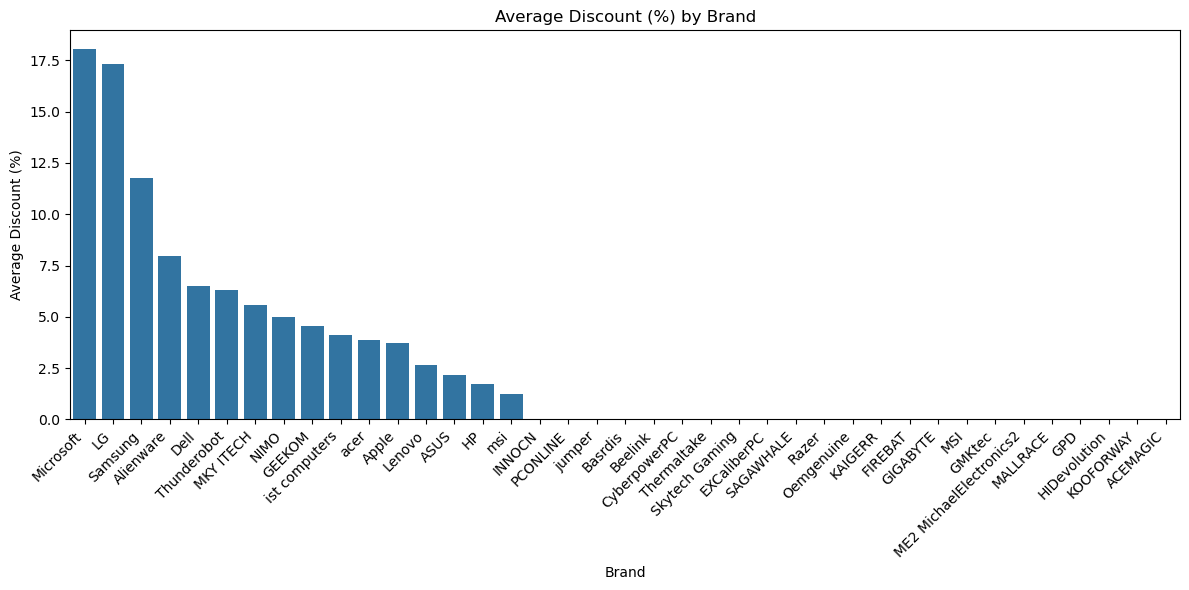

In [ ]:
# visualise the average discount by brand

plt.figure(figsize=(12,6))
sns.barplot(
    data=brand_discount,
    x="brand",
    y="discount_pct"
)

plt.xticks(rotation=45, ha="right")
plt.title("Average Discount (%) by Brand")
plt.ylabel("Average Discount (%)")
plt.xlabel("Brand")
plt.tight_layout()
plt.show()

# brands left leaning = most aggressive discounting
# premium brands often discount less
# mass market brands usually discount more

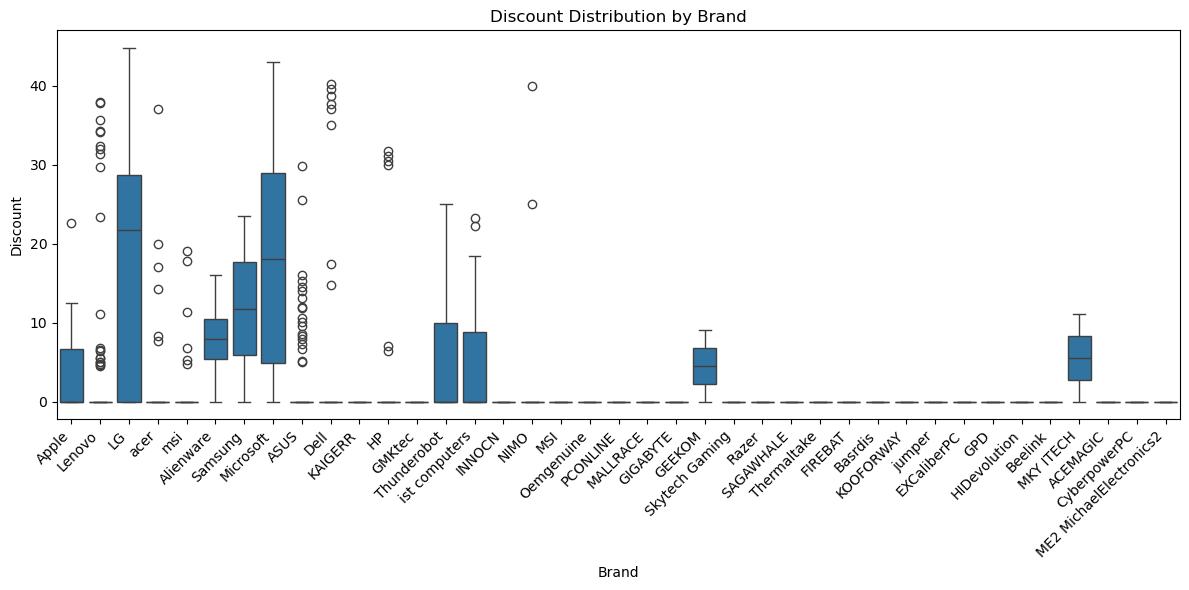

In [ ]:
# Distribution of discounts (brand behaviour insight)
# do brands constantly discount or only occasionally offer big deals?

plt.figure(figsize=(12,6))
sns.boxplot(
    data=laptops_eda,
    x="brand",
    y="discount_pct"
)

plt.xticks(rotation=45, ha="right")
plt.title("Discount Distribution by Brand")
plt.ylabel("Discount")
plt.xlabel("Brand")
plt.tight_layout()
plt.show()

# wide boxes = inconsistent discounting
# long upper whispkers = occasional deep discounts

In [8]:
# Correlation analysis (price, reviews, stars)

corr_cols = ["price", "reviews_count", "stars", "discount_pct"]
corr_matrix = laptops_eda[corr_cols].corr()

corr_matrix

,price,reviews_count,stars,discount_pct
price,1.000000,-0.032299,0.049853,-0.156464
reviews_count,-0.032299,1.000000,0.010261,0.035707
stars,0.049853,0.010261,1.000000,0.012186
discount_pct,-0.156464,0.035707,0.012186,1.000000


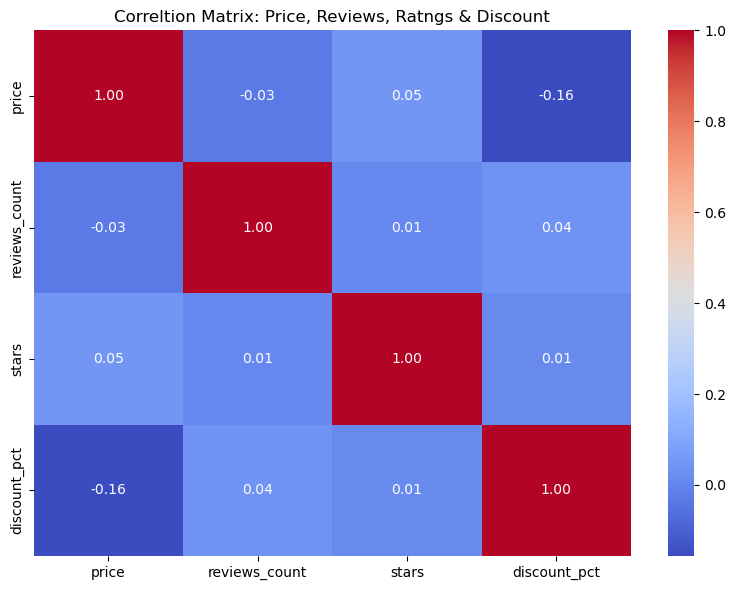

In [9]:
# visualise correlation heatmap

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correltion Matrix: Price, Reviews, Ratngs & Discount")
plt.tight_layout()
plt.show()

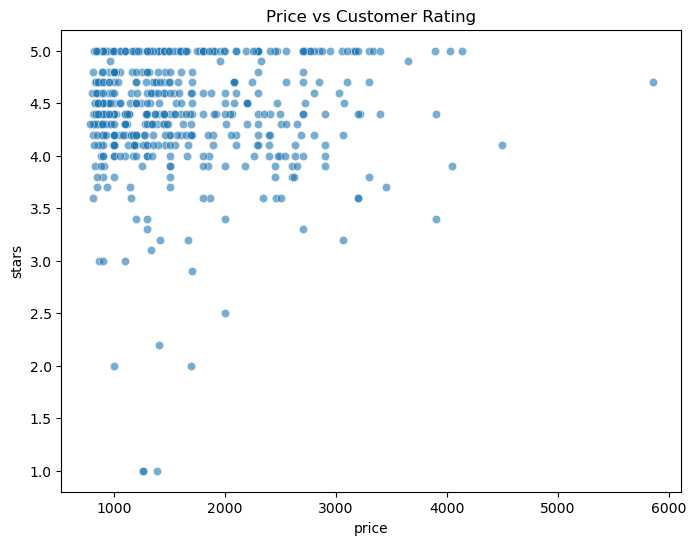

In [10]:
# scatter plots 
# price v stars

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=laptops_eda,
    x="price",
    y="stars",
    alpha=0.6
)

plt.title("Price vs Customer Rating")
plt.show()

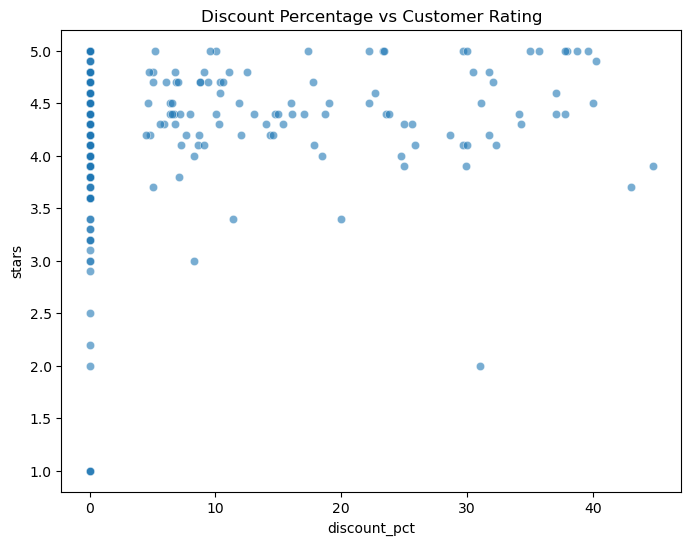

In [11]:
# Discount vs Stars

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=laptops_eda,
    x="discount_pct",
    y="stars",
    alpha=0.6
)

plt.title("Discount Percentage vs Customer Rating")
plt.show()